## SDM274 Assignment 08 - Multi-class Classification

### Requirements

In this assignment, you will leverage Python programming language and the Numpy library to construct a Multilayer Perceptron (MLP) model to address the multi-class classification problem of handwritten digit recognition. The dataset is sourced from the Optical Recognition of Handwritten Digits dataset available in the UCI Machine Learning Repository.

**Dataset Description**:

- Training dataset: optdigits.tra
- Testing dataset: optdigits.tes

**Data Format**:

- Each row in the training and testing datasets represents a handwritten digit image.
- Columns 0 to 63 represent the input features, which are composed of 8x8 pixel images' grayscale values, reflecting the image's grayscale levels.
- Column 64 (the 65th column) is the output class (label), ranging from 0 to 9, corresponding to different handwritten digits.

**Assignment Tasks**:

1. Construct a Multilayer Perceptron (MLP) model using Numpy.
2. Train your MLP model using the training dataset optdigits.tra.
3. Evaluate your MLP model's performance using the testing dataset optdigits.tes.
4. Calculate and report the classification accuracy of your model on the test dataset.

**Submission Requirements**:

1. Your implementation code for the MLP model.
2. Code for training the model.
3. Code for testing and calculating accuracy.
4. A brief report describing your model structure, training process, and test results.

Ensure that your code is well-organized and sufficiently commented for clarity. Additionally, when evaluating your model's performance, consider using appropriate metrics and discuss potential factors that may influence the model's performance.

In [1]:
import warnings
warnings.filterwarnings("ignore", category = FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from simple_ml.model import *
from simple_ml.model.layers import *
from simple_ml.data.dataset import *
from simple_ml.data.samples import *
from simple_ml.training.loss import *
from simple_ml.training.optimizer import *
from simple_ml.evaluation.criterion import *

### Data Preparation

Read the data from the dataset, which has been divided into a training set and a test set.

Note that the labels take values in the range 0-9, which we need to convert to One-Hot encoding. Our `simple_ml` framework provides interfaces that allow the user to pass in the division function as shown in `label_split_for_one_hot_output_dataset` below.

In [2]:
train_csv = pd.read_csv('optdigits.tra', header = None)
test_csv = pd.read_csv('optdigits.tes', header = None)

def label_split_for_one_hot_output_dataset(data: np.ndarray):
    return [data[:, :-1], np.eye(10)[data[:, -1]]] # [[x_1, x_2], [t_0, t_1, ..., t_9]]

train_dataset = Dataset(data = train_csv.values, preprocess_func = label_split_for_one_hot_output_dataset)
test_dataset = Dataset(data = test_csv.values, preprocess_func = label_split_for_one_hot_output_dataset)

Shows examples of some of the images in the training set and the corresponding labels.

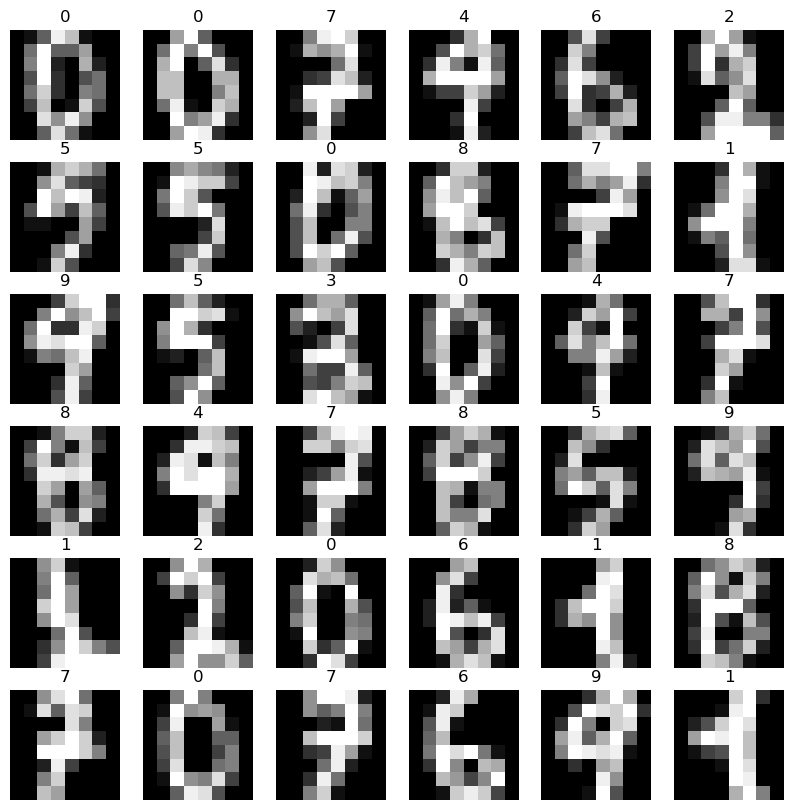

In [3]:
fig, ax = plt.subplots(6, 6, figsize = (10, 10))
for i in range(6):
    for j in range(6):
        ax[i, j].imshow(train_dataset[i * 6 + j][0].reshape(8, 8), cmap = 'gray')
        ax[i, j].set_title(np.argmax(train_dataset[i * 6 + j][1]))
        ax[i, j].axis('off')
plt.show()

### Model Training

First build the model. We use an MLP model containing 64 input neurons, 10 output neurons, containing a hidden layer of 128 neurons. We use the `Sigmoid` activation function and finally the `SoftmaxCrossEntropyLoss` which is a Softmax and multicategorical cross-entropy loss function in one.

Epoch: 100 / 1000
Epoch: 200 / 1000
Epoch: 300 / 1000
Epoch: 400 / 1000
Epoch: 500 / 1000
Epoch: 600 / 1000
Epoch: 700 / 1000
Epoch: 800 / 1000
Epoch: 900 / 1000
Epoch: 1000 / 1000


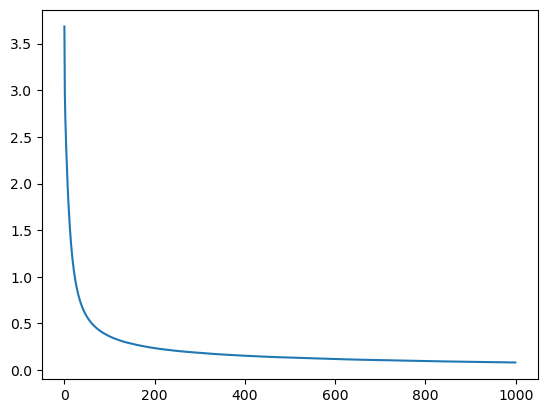

In [19]:
model = Sequential([
    Linear(64, 128),
    Sigmoid(),
    Linear(128, 10)
])
loss_func = SoftmaxCrossEntropyLoss()
optimizer = GD(model.parameters(), lr = 0.003)

train_iter = DataIterator(train_dataset, batch_size = 32, shuffle = True, cyclic = False)

epoch_num = 1000

train_loss_buffer = []

for epoch in range(epoch_num):
    train_loss = 0

    for batch, [features, labels] in enumerate(train_iter):
        prediction = model(Variable(features))
        loss = loss_func(prediction, labels)

        model.backward()
        optimizer.step()

        train_loss += loss
    
    train_loss /= len(train_dataset)
    train_loss_buffer.append(train_loss)

    if (epoch + 1) % (epoch_num // 10) == 0:
        print(f'Epoch: {epoch + 1} / {epoch_num}')

fig = plt.figure(1)
plt.plot(np.arange(len(train_loss_buffer)), train_loss_buffer)
plt.show()

### Evaluation

The model is evaluated using a test set and the accuracy is calculated.

Multiclass Accuracy is calculated using `eval_multiclass_accuracy`:

```python
def eval_multiclass_accuracy(Y: Union[Variable, np.ndarray], T: np.ndarray):
    """
        Y: the output of the model (probabilities of each class)
        T: the target (label) of the model output (one-hot encoding)
    """
    if isinstance(Y, Variable):
        Y = Y.value
    Y = np.argmax(Y, axis = 1)
    T = np.argmax(T, axis = 1)
    return np.mean(Y == T)
```

In [20]:
test_prediction = model(Variable(test_dataset.datas[0]))
test_accuracy = eval_multiclass_accuracy(test_prediction, test_dataset.datas[1])
print(f'Test Accuracy: {test_accuracy:.4f}')

Test Accuracy: 0.9405


### Discussion

By adjusting the number of hidden layer neurons, the number of hidden layers, and the hyperparameters (e.g., learning rate, number of iterations, etc.) during the training process, the model was found to converge well in most of the cases after several tests and did not show any obvious overfitting.